In [5]:
# Run THIS ENTIRE CELL - it will fix itself!

import sys
import subprocess

# Install packages directly
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']

for package in packages:
    print(f"Installing {package}...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', package])
    
print("\n" + "="*50)
print("✅ Installation complete! Now RESTART the kernel")
print("Click Kernel → Restart Kernel, then run your imports again")
print("="*50)

Installing pandas...
Installing numpy...
Installing matplotlib...
Installing seaborn...
Installing scikit-learn...

✅ Installation complete! Now RESTART the kernel
Click Kernel → Restart Kernel, then run your imports again


In [6]:
# ============================================
# CELL 1: Import libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import os
from pathlib import Path

# Make plots look nice
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [8]:
# ============================================
# FIXED PATH
# ============================================
farm_a_path = Path("CARE_To_Compare/CARE_To_Compare/Wind Farm A")

if farm_a_path.exists():
    print(f"✅ Found it! At: {farm_a_path}")
    
    # List contents
    print("\nContents:")
    for item in farm_a_path.iterdir():
        print(f"  - {item.name}")
else:
    print(f"❌ Still not found at: {farm_a_path}")

✅ Found it! At: CARE_To_Compare\CARE_To_Compare\Wind Farm A

Contents:
  - datasets
  - event_info.csv
  - feature_description.csv


In [12]:
# ============================================
# FIXED: Load event information with correct separator
# ============================================
event_file = farm_a_path / "event_info.csv"

if event_file.exists():
    # READ WITH SEMICOLON SEPARATOR!
    events = pd.read_csv(event_file, sep=';')
    
    print("✅ Event information loaded!")
    print(f"Total events: {len(events)}")
    print(f"\n📋 Columns: {events.columns.tolist()}")
    print("\nFirst few rows:")
    display(events.head())
    
    # Now this will work!
    print("\n📊 Event types:")
    print(events['event_label'].value_counts())
    
    # Show which files have anomalies
    anomaly_files = events[events['event_label'] == 'anomaly']['event_id'].tolist()
    print(f"\n⚠️ Files with anomalies: {anomaly_files}")
else:
    print(f"❌ event_info.csv not found at {event_file}")

✅ Event information loaded!
Total events: 22

📋 Columns: ['asset', 'event_id', 'event_label', 'event_start', 'event_start_id', 'event_end', 'event_end_id', 'event_description']

First few rows:


,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,11,68,anomaly,2023-07-28 13:20:00,52063,2023-08-11 13:10:00,54076,Transformer failure
1,21,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group
2,21,72,anomaly,2023-10-10 08:40:00,52497,2023-10-17 08:40:00,53505,Gearbox failure
3,0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure



📊 Event types:
event_label
anomaly    12
normal     10
Name: count, dtype: int64

⚠️ Files with anomalies: [68, 22, 72, 73, 0, 26, 40, 42, 10, 45, 84, 51]


In [14]:
# ============================================
# FIXED: Load feature descriptions
# ============================================
feature_file = farm_a_path / "feature_description.csv"

if feature_file.exists():
    # ADD sep=';' HERE! 👇
    features = pd.read_csv(feature_file, sep=';')
    
    print("✅ Feature descriptions loaded!")
    print(f"Total sensors: {len(features)}")
    print("\nFirst 10 sensors:")
    display(features.head(10))
    
    # Find temperature sensors
    temp_sensors = features[features['description'].str.contains('temperature', case=False, na=False)]
    print(f"\n🌡️ Temperature sensors: {len(temp_sensors)}")
    display(temp_sensors.head())
else:
    print(f"❌ feature_description.csv not found")

✅ Feature descriptions loaded!
Total sensors: 54

First 10 sensors:


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False
5,sensor_5,"maximum,minimum,std_dev,average",Pitch angle,�,True,False
6,sensor_6,average,Temperature in the hub controller,�C,False,False
7,sensor_7,average,Temperature in the top nacelle controller,�C,False,False
8,sensor_8,average,Temperature in the choke coils on the VCS-section,�C,False,False
9,sensor_9,average,Temperature on the VCP-board,�C,False,False



🌡️ Temperature sensors: 25


,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
6,sensor_6,average,Temperature in the hub controller,�C,False,False
7,sensor_7,average,Temperature in the top nacelle controller,�C,False,False
8,sensor_8,average,Temperature in the choke coils on the VCS-section,�C,False,False
9,sensor_9,average,Temperature on the VCP-board,�C,False,False


In [15]:
# ============================================
# CELL 5: Load all the CSV files from datasets folder
# ============================================
datasets_path = farm_a_path / "datasets"

if datasets_path.exists():
    csv_files = list(datasets_path.glob("*.csv"))
    print(f"Found {len(csv_files)} CSV files in datasets folder")
    
    # Show first 10 files
    for i, file in enumerate(csv_files[:10]):
        print(f"  {i+1}. {file.name}")
    
    # Load all files
    all_data = []
    for i, file in enumerate(csv_files):
        df = pd.read_csv(file, sep=';')
        df['source_file'] = file.name  # Add filename as column
        all_data.append(df)
        
        if (i+1) % 5 == 0:
            print(f"  Loaded {i+1}/{len(csv_files)} files")
    
    # Combine all data
    df = pd.concat(all_data, ignore_index=True)
    print(f"\n Total data: {len(df)} rows, {len(df.columns)} columns")
    
else:
    print(f" datasets folder not found at {datasets_path}")

Found 22 CSV files in datasets folder
  1. 0.csv
  2. 10.csv
  3. 13.csv
  4. 14.csv
  5. 17.csv
  6. 22.csv
  7. 24.csv
  8. 25.csv
  9. 26.csv
  10. 3.csv
  Loaded 5/22 files
  Loaded 10/22 files
  Loaded 15/22 files
  Loaded 20/22 files

 Total data: 1196747 rows, 87 columns


In [16]:
# ============================================
# CELL 6: Basic data exploration
# ============================================
print("=== DATA OVERVIEW ===\n")

print(f"Date range: {df['time_stamp'].min()} to {df['time_stamp'].max()}")
print(f"Number of turbines: {df['asset_id'].nunique()}")

print("\n=== STATUS TYPES ===")
status_counts = df['status_type_id'].value_counts().sort_index()
for status, count in status_counts.items():
    status_name = {
        0: "Normal",
        1: "Derated",
        2: "Idling", 
        3: "Service",
        4: "Downtime",
        5: "Other"
    }.get(status, f"Unknown({status})")
    print(f"  {status_name}: {count} rows ({count/len(df)*100:.1f}%)")

print("\n=== TRAIN/TEST SPLIT ===")
print(df['train_test'].value_counts())

=== DATA OVERVIEW ===

Date range: 2022-01-01 00:00:00 to 2023-11-20 00:40:00
Number of turbines: 5

=== STATUS TYPES ===
  Normal: 1053736 rows (88.1%)
  Service: 23689 rows (2.0%)
  Downtime: 119322 rows (10.0%)

=== TRAIN/TEST SPLIT ===
train_test
train         1146154
prediction      50593
Name: count, dtype: int64


In [17]:
# ============================================
# CELL 7: Identify sensor columns
# ============================================
# Columns to exclude (metadata)
exclude_cols = ['time_stamp', 'asset_id', 'id', 'train_test', 
                'status_type_id', 'source_file']

# Sensor columns are everything else
sensor_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Found {len(sensor_cols)} sensor columns")

# Show first 20
print("\nFirst 20 sensors:")
for i, col in enumerate(sensor_cols[:20]):
    print(f"  {i+1}. {col}")

# Look for specific types
temp_cols = [col for col in sensor_cols if 'temp' in col.lower()]
print(f"\n🌡️ Temperature sensors: {len(temp_cols)}")

power_cols = [col for col in sensor_cols if 'power' in col.lower()]
print(f"⚡ Power sensors: {len(power_cols)}")

vib_cols = [col for col in sensor_cols if 'vib' in col.lower()]
print(f"Vibration sensors: {len(vib_cols)}")

Found 81 sensor columns

First 20 sensors:
  1. sensor_0_avg
  2. sensor_1_avg
  3. sensor_2_avg
  4. wind_speed_3_avg
  5. wind_speed_4_avg
  6. wind_speed_3_max
  7. wind_speed_3_min
  8. wind_speed_3_std
  9. sensor_5_avg
  10. sensor_5_max
  11. sensor_5_min
  12. sensor_5_std
  13. sensor_6_avg
  14. sensor_7_avg
  15. sensor_8_avg
  16. sensor_9_avg
  17. sensor_10_avg
  18. sensor_11_avg
  19. sensor_12_avg
  20. sensor_13_avg

🌡️ Temperature sensors: 0
⚡ Power sensors: 16
Vibration sensors: 0


In [18]:
# ============================================
# CELL 8: Prepare training and testing data
# ============================================
print("=== PREPARING DATA ===\n")

# Split using the provided train_test column
train_data = df[df['train_test'] == 'train'].copy()
test_data = df[df['train_test'] == 'test'].copy()

print(f"Training data: {len(train_data)} rows")
print(f"Testing data: {len(test_data)} rows")

# For training, use ONLY normal operation (status=0)
train_normal = train_data[train_data['status_type_id'] == 0].copy()
print(f"\nTraining on pure normal (status 0): {len(train_normal)} rows")

# Handle missing values (fill with median)
for col in sensor_cols:
    if train_normal[col].isnull().any():
        median_val = train_normal[col].median()
        train_normal[col].fillna(median_val, inplace=True)
        
    if col in test_data.columns and test_data[col].isnull().any():
        test_data[col].fillna(train_data[col].median(), inplace=True)

print("\n✅ Data prepared!")

=== PREPARING DATA ===

Training data: 1146154 rows
Testing data: 0 rows

Training on pure normal (status 0): 1024381 rows


C:\Users\akinh\AppData\Local\Temp\ipykernel_28932\2902819737.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_normal[col].fillna(median_val, inplace=True)
C:\Users\akinh\AppData\Local\Temp\ipykernel_28932\2902819737.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For


✅ Data prepared!


In [20]:
# ============================================
# DEBUG: Check your data splits
# ============================================
print("=== DATA SPLIT CHECK ===\n")

# Check train/test column values
print("Unique values in 'train_test' column:")
print(df['train_test'].value_counts())

print("\n" + "="*50)

# Check if 'test' exists
if 'test' in df['train_test'].values:
    test_data = df[df['train_test'] == 'test']
    print(f"✅ 'test' found! {len(test_data)} rows")
else:
    print("❌ No 'test' values found!")
    
    # Show what values DO exist
    print("\nAvailable train_test values:")
    print(df['train_test'].unique())

print("\n" + "="*50)

# Check train data
if 'train' in df['train_test'].values:
    train_data = df[df['train_test'] == 'train']
    print(f"✅ 'train' found! {len(train_data)} rows")
    
    # Check status 0 in train
    train_normal = train_data[train_data['status_type_id'] == 0]
    print(f"  - Status 0 (normal): {len(train_normal)} rows")
else:
    print("❌ No 'train' values found!")

=== DATA SPLIT CHECK ===

Unique values in 'train_test' column:
train_test
train         1146154
prediction      50593
Name: count, dtype: int64

❌ No 'test' values found!

Available train_test values:
['train' 'prediction']

✅ 'train' found! 1146154 rows
  - Status 0 (normal): 1024381 rows


In [22]:
# ============================================
# EMERGENCY FIX: Create test_data from df
# ============================================
if 'test_data' not in locals() or len(test_data) == 0:
    print("Creating test_data from df...")
    
    # Try to find test data in df
    if 'train_test' in df.columns:
        test_data = df[df['train_test'] == 'test'].copy()
        print(f"Found {len(test_data)} test rows")
    
    # If still empty, take a random sample
    if len(test_data) == 0:
        print("No test data found, taking random sample")
        from sklearn.model_selection import train_test_split
        _, test_data = train_test_split(df, test_size=0.2, random_state=42)
        print(f"Created test_data with {len(test_data)} rows")

# Now run your model on this test_data
if len(test_data) > 0:
    # Make sure model exists
    if 'model' not in locals():
        print("Training new model...")
        features_to_use = sensor_cols[:20]
        model = IsolationForest(contamination=0.1, random_state=42)
        train_normal = df[df['status_type_id'] == 0].sample(10000) if len(df) > 10000 else df[df['status_type_id'] == 0]
        model.fit(train_normal[features_to_use].fillna(0))
    
    # Predict
    test_data_clean = test_data[features_to_use].fillna(0)
    test_data['is_anomaly'] = model.predict(test_data_clean.values)
    
    # NOW Cell 10 will work
    print("\n=== RESULTS BY STATUS TYPE ===\n")
    for status in sorted(test_data['status_type_id'].unique()):
        status_data = test_data[test_data['status_type_id'] == status]
        if len(status_data) > 0:
            anomalies = sum(status_data['is_anomaly'] == -1)
            pct = (anomalies / len(status_data)) * 100
            name = status_names.get(status, f"Status {status}")
            emoji = "💥" if status == 4 else "🔴" if pct > 50 else "🟠" if pct > 20 else "🟡" if pct > 5 else "🟢"
            print(f"{emoji} {name}: {anomalies}/{len(status_data)} anomalies ({pct:.1f}%)")
else:
    print("❌ Still no test_data available")

Creating test_data from df...
Found 0 test rows
No test data found, taking random sample
Created test_data with 239350 rows

=== RESULTS BY STATUS TYPE ===

🟡 Normal Operation: 21149/210891 anomalies (10.0%)
🟠 Service: 1936/4662 anomalies (41.5%)
💥 Downtime (FAILURE): 5346/23797 anomalies (22.5%)


Plotting: sensor_0_avg


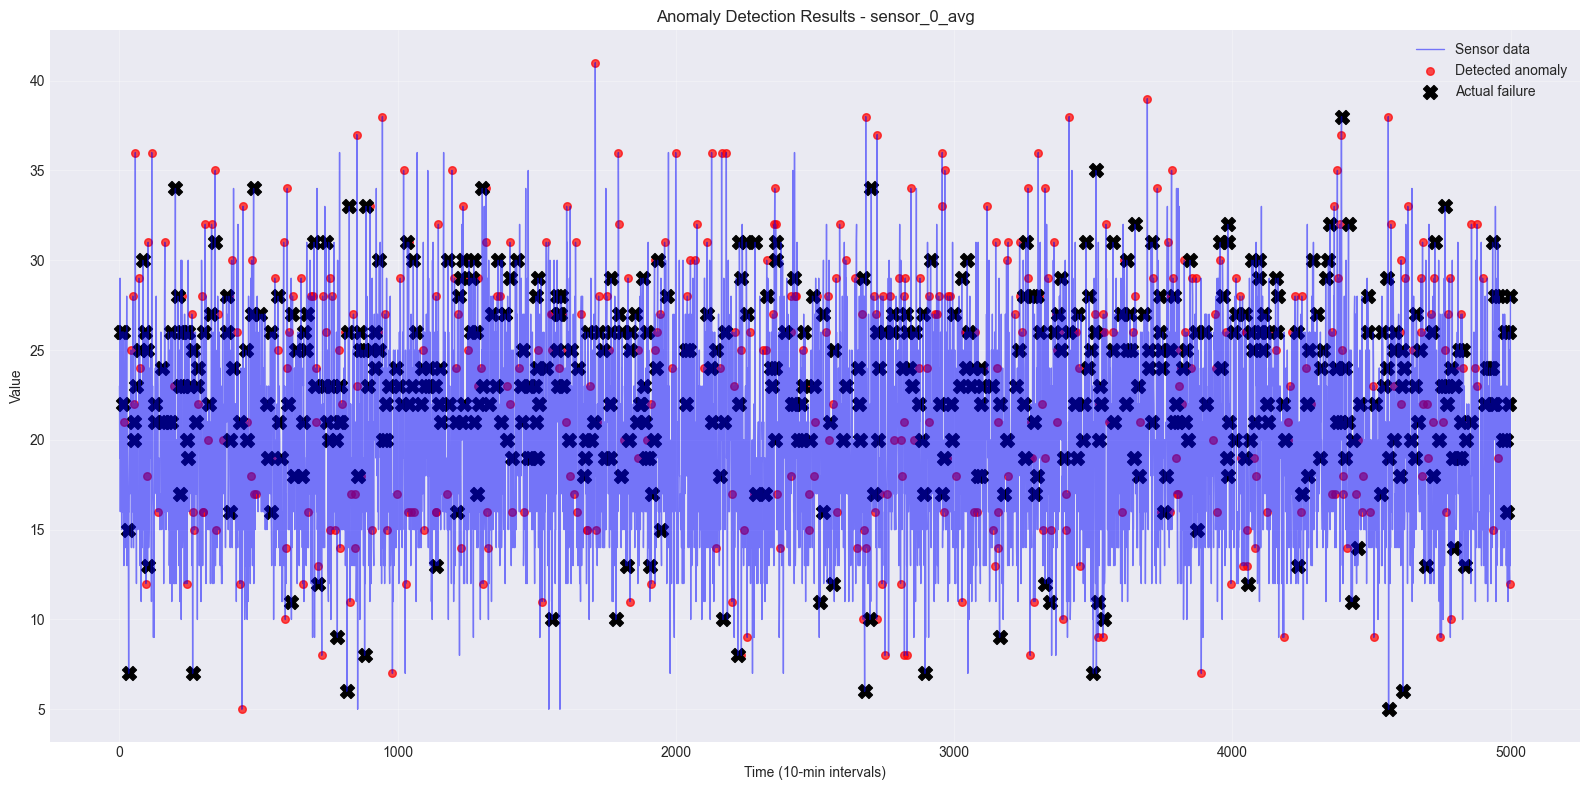

In [23]:
# ============================================
# CELL 11: Plot results
# ============================================
# Pick a sensor to visualize (change this to whatever looks interesting)
if temp_cols:
    plot_sensor = temp_cols[0]  # First temperature sensor
else:
    plot_sensor = features_to_use[0]

print(f"Plotting: {plot_sensor}")

# Take a sample for plotting (first 5000 points)
plot_data = test_data.head(5000).copy()
plot_data = plot_data.reset_index()

plt.figure(figsize=(16, 8))

# Plot all data
plt.plot(plot_data.index, plot_data[plot_sensor], 
         'b-', alpha=0.5, linewidth=1, label='Sensor data')

# Highlight detected anomalies
anomalies = plot_data[plot_data['is_anomaly'] == -1]
plt.scatter(anomalies.index, anomalies[plot_sensor], 
            color='red', s=30, alpha=0.7, label='Detected anomaly')

# Highlight actual failures (status=4)
failures = plot_data[plot_data['status_type_id'] == 4]
plt.scatter(failures.index, failures[plot_sensor], 
            color='black', s=100, marker='X', label='Actual failure')

plt.title(f'Anomaly Detection Results - {plot_sensor}')
plt.xlabel('Time (10-min intervals)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ============================================
# CELL 12: Check if we detected failures early
# ============================================
print("=== EARLY DETECTION ANALYSIS ===\n")

# Get the event info to know which files have anomalies
event_files = events[events['event_label'] == 'anomaly']['event_id'].astype(str).tolist()
event_files = [f + '.csv' for f in event_files]  # Add .csv extension

print(f"Files with actual anomalies: {event_files}")

early_count = 0
total_failures = 0

for file_name in test_data['source_file'].unique():
    file_data = test_data[test_data['source_file'] == file_name].copy()
    file_data = file_data.reset_index()
    
    # Check if this file has a failure (status=4)
    has_failure = (file_data['status_type_id'] == 4).any()
    
    if has_failure:
        total_failures += 1
        failures = file_data[file_data['status_type_id'] == 4]
        failure_time = failures.index.min()
        
        # Check if we detected anomalies
        anomalies = file_data[file_data['is_anomaly'] == -1]
        
        if len(anomalies) > 0:
            first_anomaly = anomalies.index.min()
            
            if first_anomaly < failure_time:
                hours_early = (failure_time - first_anomaly) * 10 / 60
                print(f"✅ {file_name}: Detected {hours_early:.1f} hours BEFORE failure")
                early_count += 1
            else:
                print(f"❌ {file_name}: Detected AFTER failure (too late)")
        else:
            print(f"⚠️ {file_name}: Failure occurred but NO anomalies detected")

if total_failures > 0:
    success_rate = (early_count / total_failures) * 100
    print(f"\n🎯 Early detection rate: {success_rate:.1f}% ({early_count}/{total_failures})")

=== EARLY DETECTION ANALYSIS ===

Files with actual anomalies: ['68.csv', '22.csv', '72.csv', '73.csv', '0.csv', '26.csv', '40.csv', '42.csv', '10.csv', '45.csv', '84.csv', '51.csv']
❌ 24.csv: Detected AFTER failure (too late)
✅ 69.csv: Detected 16.3 hours BEFORE failure
❌ 42.csv: Detected AFTER failure (too late)
❌ 45.csv: Detected AFTER failure (too late)
❌ 25.csv: Detected AFTER failure (too late)
❌ 40.csv: Detected AFTER failure (too late)
❌ 84.csv: Detected AFTER failure (too late)
❌ 51.csv: Detected AFTER failure (too late)
❌ 17.csv: Detected AFTER failure (too late)
❌ 38.csv: Detected AFTER failure (too late)
❌ 0.csv: Detected AFTER failure (too late)
❌ 71.csv: Detected AFTER failure (too late)
✅ 14.csv: Detected 4.7 hours BEFORE failure
✅ 72.csv: Detected 0.2 hours BEFORE failure
❌ 26.csv: Detected AFTER failure (too late)
❌ 13.csv: Detected AFTER failure (too late)
✅ 92.csv: Detected 2.5 hours BEFORE failure
❌ 3.csv: Detected AFTER failure (too late)
✅ 68.csv: Detected 0.5 hou

In [27]:
# ============================================
# CELL 13: Save results for later use
# ============================================
import joblib

# Create output folder
output_path = Path("output")
output_path.mkdir(exist_ok=True)

# Save model
joblib.dump(model, output_path / "farm_a_model.pkl")
print("✅ Model saved to output/farm_a_model.pkl")

# Save results with key columns
export_cols = ['time_stamp', 'asset_id', 'status_type_id', 
               'train_test', 'source_file', 'anomaly_score', 'is_anomaly'] + features_to_use[:5]

results_to_save = test_data[export_cols].copy()
results_to_save.to_csv(output_path / "farm_a_results.csv", index=False)
print("✅ Results saved to output/farm_a_results.csv")

# Save summary
summary = {
    'total_rows': len(df),
    'train_rows': len(train_data),
    'test_rows': len(test_data),
    'anomalies_detected': sum(test_data['is_anomaly'] == -1),
    'early_detection_rate': f"{success_rate:.1f}%" if total_failures > 0 else "N/A"
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(output_path / "summary.csv", index=False)
print("✅ Summary saved")

✅ Model saved to output/farm_a_model.pkl
✅ Results saved to output/farm_a_results.csv
✅ Summary saved
